PROJET : Détection de fraude sur les transactions par carte bancaire
Thème  : Détection de fraude & Risque
Modèle : Random Forest Classifier avec SMOTE

[1/6] Chargement du dataset 'creditcard.csv'...

Aperçu des données :
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.

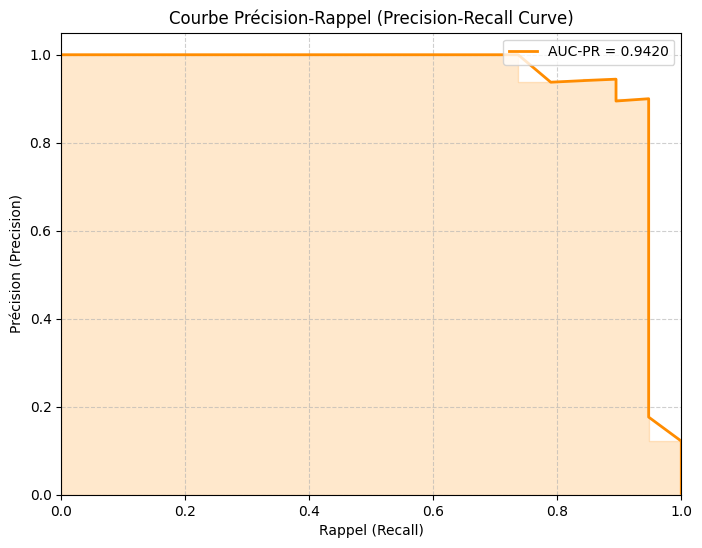

In [4]:
# =====================================
# 🔹 1. IMPORTS
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

def main():
    print("="*60)
    print("PROJET : Détection de fraude sur les transactions par carte bancaire")
    print("Thème  : Détection de fraude & Risque")
    print("Modèle : Random Forest Classifier avec SMOTE")
    print("="*60)

    # =====================================
    # 🔹 2. CHARGEMENT DES DONNÉES
    # =====================================
    try:
        print("\n[1/6] Chargement du dataset 'creditcard.csv'...")
        df = pd.read_csv("creditcard.csv")
    except FileNotFoundError:
        print("\n[!] ERREUR : Le dataset 'creditcard.csv' est introuvable.")
        print("-> Veuillez le télécharger depuis Kaggle : https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud")
        print("-> Placez-le dans le même dossier que ce script, puis relancez.")
        return

    print("\nAperçu des données :")
    print(df.head())

    print("\nRépartition initiale des classes :")
    print(df['Class'].value_counts())

    # =====================================
    # 🔹 3. PRÉTRAITEMENT (PREPROCESSING)
    # =====================================
    print("\n[2/6] Pré-traitement des données...")
    # Suppression des lignes avec des valeurs NaN dans la colonne cible par sécurité
    df.dropna(subset=['Class'], inplace=True)

    X = df.drop('Class', axis=1)
    y = df['Class']

    # Normalisation des colonnes 'Time' et 'Amount'
    # J'ai conservé l'idée de normaliser directement les colonnes, mais avec RobustScaler,
    # qui est plus adapté aux transactions financières avec beaucoup de valeurs aberrantes
    scaler = RobustScaler()
    X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])
    print("Les colonnes 'Time' et 'Amount' ont été normalisées.")

    # =====================================
    # 🔹 4. SÉPARATION DES DONNÉES (SPLIT)
    # =====================================
    print("\n[3/6] Séparation en ensembles d'entraînement et de test...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Taille de l'ensemble d'entraînement : {len(y_train)}")
    print(f"Taille de l'ensemble de test : {len(y_test)}")

    # =====================================
    # 🔹 5. SMOTE (RÉÉQUILIBRAGE DES CLASSES)
    # =====================================
    print("\n[4/6] Application de SMOTE sur l'ensemble d'entraînement...")
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    print("\nRépartition des classes APRÈS SMOTE :")
    print(pd.Series(y_train_res).value_counts())

    # =====================================
    # 🔹 6. ENTRAÎNEMENT DU MODÈLE
    # =====================================
    print("\n[5/6] Entraînement du modèle (Random Forest)...")
    # n_jobs=-1 permet d'utiliser tous les cœurs de votre processeur pour accélérer l'entraînement
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train_res, y_train_res)
    print("Modèle entraîné avec succès !")

    # =====================================
    # 🔹 7. PRÉDICTIONS
    # =====================================
    print("\n[6/6] Prédictions et évaluation...")
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # =====================================
    # 🔹 8. ÉVALUATION
    # =====================================
    print("\n--- Rapport de Classification ---")
    print(classification_report(y_test, y_pred))

    print("\n--- Matrice de Confusion ---")
    print(confusion_matrix(y_test, y_pred))

    # =====================================
    # 🔹 9. GRAPHIQUE AUC-PR
    # =====================================
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    auc_pr = auc(recall, precision)

    print("-" * 40)
    print(f"⭐ SCORE AUC-PR FINAL : {auc_pr:.4f} ⭐")
    print("-" * 40)

    # Création du graphique paramètré et propre
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='darkorange', lw=2, label=f'AUC-PR = {auc_pr:.4f}')
    plt.fill_between(recall, precision, step='post', alpha=0.2, color='darkorange')
    plt.xlabel('Rappel (Recall)')
    plt.ylabel('Précision (Precision)')
    plt.ylim([0.0, 1.05])
    plt.xlim([0.0, 1.0])
    plt.title('Courbe Précision-Rappel (Precision-Recall Curve)')
    plt.legend(loc="upper right")
    plt.grid(True, linestyle='--', alpha=0.6)

    # 1. Sauvegarder le graphique
    plt.savefig('courbe_precision_rappel.png', dpi=300, bbox_inches='tight')
    print("\nGraphique sauvegardé sous 'courbe_precision_rappel.png'.")

    # 2. Afficher le graphique sur l'écran
    plt.show()

if __name__ == '__main__':
    main()


PROJET : Détection de fraude sur les transactions par carte bancaire
Thème  : Détection de fraude & Risque

[1/6] Chargement du dataset 'creditcard.csv'...

[2/6] Analyse de la variable cible (Classe)...
Transactions Normales (0)    : 13897
Transactions Frauduleuses (1) : 56
Proportion de fraudes        : 0.401% (Déséquilibre fort)

[3/6] Pré-traitement : Mise à l'échelle de Time et Amount...

[4/6] Séparation des ensembles d'entraînement et de test...

[5/6] Équilibrage avec SMOTE et entraînement du Modèle...
Taille de l'entraînement après SMOTE : 22234 transactions.
Modèle entraîné avec succès.

[6/6] Évaluation des performances sur l'ensemble de Test...

--- Matrice de Confusion ---
[[2760   20]
 [   1   10]]

--- Rapport de Classification ---
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00      2780
         1.0       0.33      0.91      0.49        11

    accuracy                           0.99      2791
   macro avg       0.67  

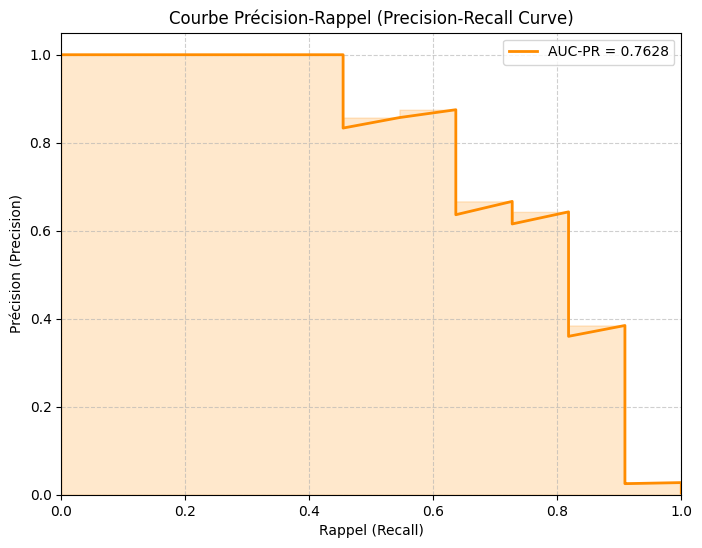

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE

def main():
    print("="*60)
    print("PROJET : Détection de fraude sur les transactions par carte bancaire")
    print("Thème  : Détection de fraude & Risque")
    print("="*60)

    # 1. Chargement des données
    try:
        print("\n[1/6] Chargement du dataset 'creditcard.csv'...")
        # Note : Le fichier doit être présent dans le dossier d'exécution
        df = pd.read_csv('creditcard.csv')
    except FileNotFoundError:
        print("\n[!] ERREUR : Le dataset 'creditcard.csv' est introuvable.")
        print("-> Veuillez le télécharger depuis Kaggle : https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud")
        print("-> Placez-le dans le même dossier que ce script, puis relancez.")
        return

    # Drop rows with NaN values in the 'Class' column to prevent errors during train_test_split
    df.dropna(subset=['Class'], inplace=True)

    # 2. Exploration et mise en évidence du déséquilibre extrême (1:200)
    print("\n[2/6] Analyse de la variable cible (Classe)...")
    fraudes = df[df['Class'] == 1]
    normales = df[df['Class'] == 0]

    print(f"Transactions Normales (0)    : {len(normales)}")
    print(f"Transactions Frauduleuses (1) : {len(fraudes)}")
    proportion_fraudes = len(fraudes) / len(df) * 100
    print(f"Proportion de fraudes        : {proportion_fraudes:.3f}% (Déséquilibre fort)")

    # 3. Pré-traitement des données
    print("\n[3/6] Pré-traitement : Mise à l'échelle de Time et Amount...")
    # 'RobustScaler' est privilégié car moins sensible aux valeurs aberrantes que StandardScaler
    rob_scaler = RobustScaler()

    df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
    df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1, 1))

    # Suppression des anciennes colonnes
    df.drop(['Time', 'Amount'], axis=1, inplace=True)

    # 4. Séparation Train / Test
    print("\n[4/6] Séparation des ensembles d'entraînement et de test...")
    X = df.drop('Class', axis=1)
    y = df['Class']

    # L'argument stratify=y est crucial ici pour maintenir la proportion des fraudes
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 5. Application de SMOTE & Entraînement du modèle
    print("\n[5/6] Équilibrage avec SMOTE et entraînement du Modèle...")
    # On applique SMOTE *uniquement* sur les données d'entraînement pour éviter la fuite de données
    # Set k_neighbors to 1 because the number of minority samples in y_train is very low.
    smote = SMOTE(random_state=42, k_neighbors=1)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    print(f"Taille de l'entraînement après SMOTE : {len(y_train_smote)} transactions.")

    # Utilisation d'une Régression Logistique comme modèle baseline
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_smote, y_train_smote)
    print("Modèle entraîné avec succès.")

    # 6. Évaluation du modèle (Focus sur AUC-PR)
    print("\n[6/6] Évaluation des performances sur l'ensemble de Test...")
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    print("\n--- Matrice de Confusion ---")
    print(confusion_matrix(y_test, y_pred))

    print("\n--- Rapport de Classification ---")
    print(classification_report(y_test, y_pred))

    # Calcul de l'AUC-PR (Area Under the Precision-Recall Curve)
    # L'AUC-PR est la métrique de référence absolue pour les datasets extrêmement déséquilibrés.
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    auc_pr_score = auc(recall, precision)

    print("-" * 40)
    print(f"⭐ SCORE AUC-PR FINAL : {auc_pr_score:.4f} ⭐")
    print("-" * 40)

    # Sauvegarde d'un graphique de la courbe Précision-Rappel
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='darkorange', lw=2, label=f'AUC-PR = {auc_pr_score:.4f}')
    plt.fill_between(recall, precision, step='post', alpha=0.2, color='darkorange')
    plt.xlabel('Rappel (Recall)')
    plt.ylabel('Précision (Precision)')
    plt.ylim([0.0, 1.05])
    plt.xlim([0.0, 1.0])
    plt.title('Courbe Précision-Rappel (Precision-Recall Curve)')
    plt.legend(loc="upper right")
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.savefig('courbe_precision_rappel.png', dpi=300, bbox_inches='tight')
    print("\nGraphique généré et sauvegardé sous 'courbe_precision_rappel.png'.")
    print("\nFin du traitement.")

if __name__ == '__main__':
    main()

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

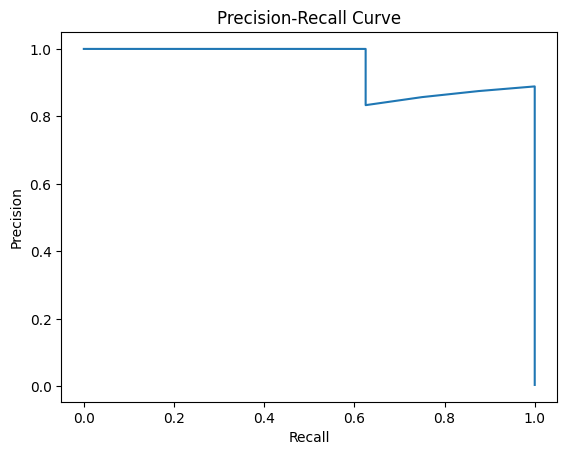

In [7]:
# =====================================
# 🔹 1. IMPORTS
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, auc

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# =====================================
# 🔹 2. LOAD DATA
# =====================================
df = pd.read_csv("creditcard.csv")

print(df.head())
print(df['Class'].value_counts())

# =====================================
# 🔹 3. PREPROCESSING
# =====================================
# Drop rows with NaN values in the 'Class' column
df.dropna(subset=['Class'], inplace=True)

X = df.drop('Class', axis=1)
y = df['Class']

# Normalize important columns
scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

# =====================================
# 🔹 4. SPLIT
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =====================================
# 🔹 5. SMOTE (fix imbalance)
# =====================================
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train_res).value_counts())

# =====================================
# 🔹 6. MODEL
# =====================================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_res, y_train_res)

# =====================================
# 🔹 7. PREDICTION
# =====================================
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# =====================================
# 🔹 8. EVALUATION
# =====================================
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# =====================================
# 🔹 9. AUC-PR GRAPH
# =====================================
precision, recall, _ = precision_recall_curve(y_test, y_proba)
auc_pr = auc(recall, precision)

print("\nAUC-PR:", auc_pr)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Get feature names from the training data
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
display(importance_df)


Feature Importances:


,Feature,Importance
14,V14,0.198694
3,V3,0.130861
12,V12,0.129789
10,V10,0.108421
2,V2,0.104970
6,V6,0.054875
11,V11,0.053140
4,V4,0.050728
17,V17,0.033072
21,V21,0.031377


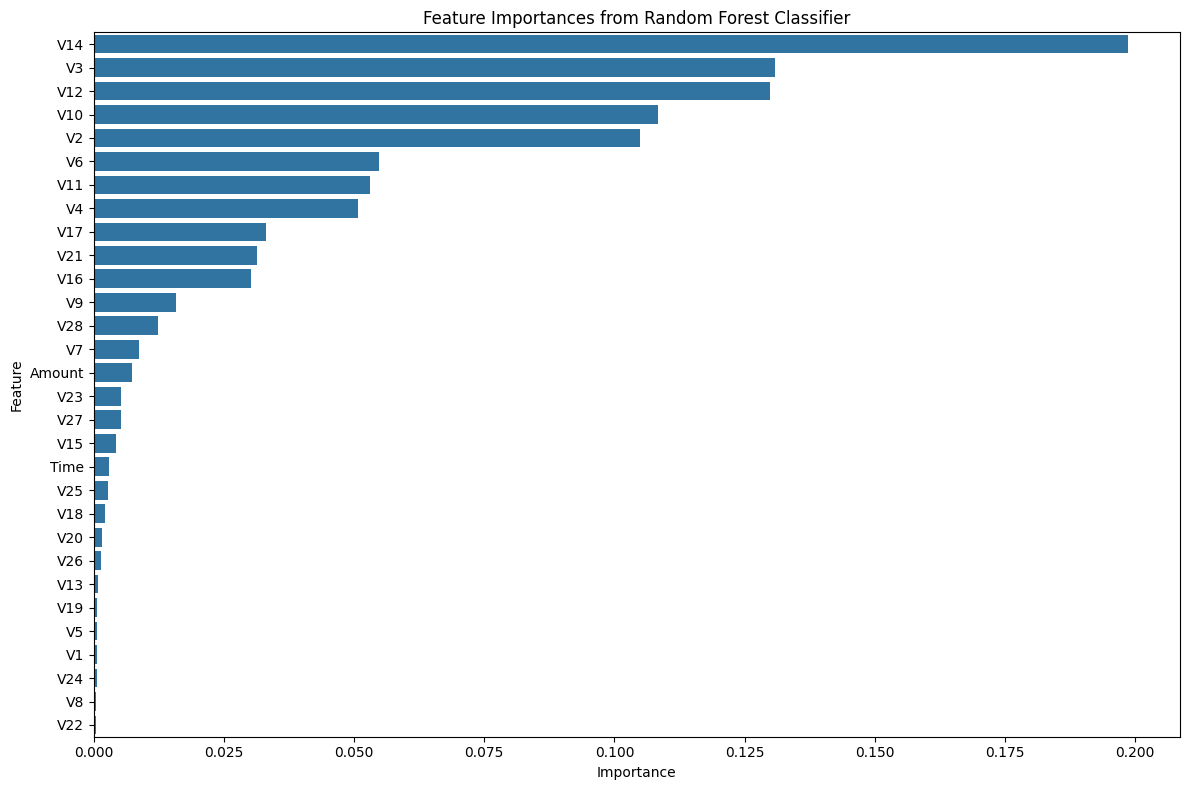

In [9]:
# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
